# Verifying the dihedral origin: $I_2^5 \subset W(A_4)$ and the Coxeter plane

Companion to `pentadic.ipynb` (cell *"The Coxeter pair $(A_4, I_2^5)$: dihedral origin of the projection"*). This notebook verifies, by exhaustive computation over the 120 elements of $W(A_4)$, the bipartite construction and the three framing facts asserted there:

1. **Stabilizer** -- $I_2^5 = \langle \sigma, \tau \rangle$ is *exactly* the subgroup of $W(A_4) \cong S_5$ stabilizing the Coxeter plane $E_\parallel$; its rotations are $\langle c \rangle$ and its five reflections are index-reversals, each fixing one coordinate.
2. **Two irreps = Galois conjugation** -- $\mathbb{R}^5 = \mathrm{trace} \oplus E_\parallel \oplus E_\perp$, and the Galois element $\rho$ of the normalizer $F_{20} = \langle c, \rho \rangle$ maps $E_\parallel$ onto $E_\perp$.
3. **Decagonal symmetry** -- $-1 \notin W(A_4)$; adjoining the lattice inversion to the induced $I_2^5$ action yields the order-20 regular-decagon group.

A coda verifies the Boyle & Steinhardt *Coxeter pair* property: the 20 roots of $A_4$ project onto $N = 2$ copies of the $I_2^5$ root system, with radius ratio $\varphi$.

**References.** J. E. Humphreys, *Reflection Groups and Coxeter Groups*, Cambridge, 1990, §§3.16-3.20; R. Steinberg, *Finite reflection groups*, Trans. Amer. Math. Soc. **91** (1959), 493-504; L. Boyle & P. J. Steinhardt, *Coxeter Pairs, Ammann Patterns and Penrose-like Tilings*, [arXiv:1608.08215](https://arxiv.org/abs/1608.08215).

Pure `numpy` -- runs on any Python 3 kernel (no SageMath required).

## 1. $W(A_4) \cong S_5$ and the simple reflections

The Weyl group of $A_4$ is $S_5$ acting on $\mathbb{R}^5$ by permuting coordinates (Humphreys §2.10); the simple reflections are the adjacent transpositions $s_i = (i,\ i{+}1)$ and the Coxeter diagram is the path $1 - 2 - 3 - 4$. We keep the full $\mathbb{R}^5$ (rather than the trace-zero hyperplane where $A_4$ properly lives) so the trace direction stays explicit, as in `pentadic.ipynb`. The cell checks the $A_4$ Coxeter relations directly.

In [16]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

def perm_matrix(p):
    """5x5 matrix of the permutation i -> p[i], acting on basis vectors e_i -> e_p[i]."""
    M = np.zeros((5, 5), dtype=int)
    for i, j in enumerate(p):
        M[j, i] = 1
    return M

def compose(p, q):
    """(p o q)(i) = p[q[i]] -- apply q first, matching the matrix product P_p @ P_q."""
    return tuple(p[q[i]] for i in range(5))

IDENT = (0, 1, 2, 3, 4)

def transposition(i, j):
    p = list(IDENT); p[i], p[j] = p[j], p[i]
    return tuple(p)

def order(p):
    q, n = p, 1
    while q != IDENT:
        q, n = compose(p, q), n + 1
    return n

# simple reflections of A4 (1-based labels as in Humphreys): s_k swaps coordinates k-1, k
s = {k: transposition(k - 1, k) for k in (1, 2, 3, 4)}

# Coxeter relations for the path diagram 1-2-3-4:
# Verify relationships in the Dynkin Diagram
#   s_i^2 = 1,   (s_i s_{i+1})^3 = 1 (adjacent),   (s_i s_j)^2 = 1 (non-adjacent)
assert all(order(s[k]) == 2 for k in s)
assert all(order(compose(s[k], s[k + 1])) == 3 for k in (1, 2, 3))
assert all(order(compose(s[i], s[j])) == 2 for i in (1, 2) for j in (3, 4) if j - i > 1)
print("A4 Coxeter relations verified for s1..s4 acting on R^5 by coordinate transpositions")

A4 Coxeter relations verified for s1..s4 acting on R^5 by coordinate transpositions


## 2. The bipartite pair $\sigma, \tau$ (Humphreys §3.17, following Steinberg)

The $A_4$ diagram is bipartite: $S = \{s_1, s_3\} \sqcup \{s_2, s_4\}$, each class consisting of mutually non-adjacent -- hence commuting -- reflections. Therefore

$$ \sigma = s_1 s_3, \qquad \tau = s_2 s_4 $$

are involutions, and $c = \sigma\tau$ is a **Coxeter element** (§3.16: a product of all simple reflections in some order; all such products are conjugate, §3.16 Prop.). Humphreys (§3.17, after Steinberg 1959) shows that $\langle \sigma, \tau \rangle$ is dihedral of order $2h$, where $h$ is the Coxeter number, and that it acts faithfully on a distinguished plane. For $A_4$, $h = 5$, so

$$ \langle \sigma, \tau \rangle \;\cong\; I_2(5) \;=\; I_2^5, \qquad |I_2^5| = 10 . $$

In [2]:
sigma = compose(s[1], s[3])      # {s1, s3} commute: product is an involution
tau   = compose(s[2], s[4])      # {s2, s4} commute: product is an involution
c     = compose(sigma, tau)

assert order(sigma) == 2 and order(tau) == 2
assert order(c) == 5
print("sigma =", sigma, "  tau =", tau, "  (both involutions)")
orb = [0]
while c[orb[-1]] != 0:
    orb.append(c[orb[-1]])
print("c = sigma tau =", c, " has order", order(c), "= h;  as a cycle:", tuple(orb))

def closure(gens):
    G = {IDENT}
    frontier = set(gens)
    while frontier:
        G |= frontier
        frontier = {compose(g, x) for g in gens for x in G} - G
    return G

D = closure([sigma, tau])
powers_c = {IDENT}
q = c
while q != IDENT:
    powers_c.add(q); q = compose(c, q)

assert len(D) == 10
assert D == powers_c | {compose(q, sigma) for q in powers_c}
print("D = <sigma, tau> has order", len(D), "= 2h, and D = <c> u <c>.sigma  (dihedral)")

sigma = (1, 0, 3, 2, 4)   tau = (0, 2, 1, 4, 3)   (both involutions)
c = sigma tau = (1, 3, 0, 4, 2)  has order 5 = h;  as a cycle: (0, 1, 3, 4, 2)
D = <sigma, tau> has order 10 = 2h, and D = <c> u <c>.sigma  (dihedral)


## 3. The Coxeter plane from the eigenvalues of $c$ (§§3.18-3.19)

The eigenvalues of a Coxeter element are $\zeta^{m}$, $\zeta = e^{2\pi i/h}$, as $m$ runs over the **exponents** of the group (Humphreys §3.19); for $A_4$ these are $m = 1, 2, 3, 4$ (degrees $2,3,4,5$). In our 5D realization the extra eigenvalue $1$ sits on the trace line. The conjugate exponent pairs $\{1, 4\}$ and $\{2, 3\}$ span two real $c$-invariant planes:

- $E_\parallel$ -- **the Coxeter plane**, on which $c$ rotates by $2\pi/5$;
- $E_\perp$ -- its Galois partner, rotation by $4\pi/5$;

and $\mathbb{R}^5 = \mathrm{trace} \oplus E_\parallel \oplus E_\perp$ as orthogonal $I_2^5$-invariant summands.

In [3]:
C = perm_matrix(c).astype(float)
zeta = np.exp(2j * np.pi / 5)
evals, evecs = np.linalg.eig(C)

def real_plane(eigenvalue):
    """Orthonormal basis (5x2) of the real plane spanned by Re, Im of the eigenvector."""
    k = int(np.argmin(np.abs(evals - eigenvalue)))
    v = evecs[:, k]
    Q, _ = np.linalg.qr(np.column_stack([v.real, v.imag]))
    return Q

V_par  = real_plane(zeta)         # exponents {1, 4}:  E_par
V_perp = real_plane(zeta ** 2)    # exponents {2, 3}:  E_perp
P_par  = V_par  @ V_par.T
P_perp = V_perp @ V_perp.T
ones   = np.ones(5) / np.sqrt(5)
assert np.allclose(P_par + P_perp + np.outer(ones, ones), np.eye(5))
print("R^5 = trace (+) E_par (+) E_perp   (orthogonal projectors sum to the identity)")

def induced(p, V):
    """2x2 matrix of permutation p restricted to the plane spanned by V (if stabilized)."""
    return V.T @ perm_matrix(p).astype(float) @ V

def stabilizes(p, P_plane):
    M = perm_matrix(p).astype(float)
    return np.allclose(M @ P_plane @ M.T, P_plane)

for name, V in (("E_par ", V_par), ("E_perp", V_perp)):
    A = induced(c, V)
    ang = abs(np.degrees(np.arctan2(A[1, 0], A[0, 0])))
    print(f"c on {name}: rotation by {ang:5.1f} deg,  det = {np.linalg.det(A):+.3f}")

R^5 = trace (+) E_par (+) E_perp   (orthogonal projectors sum to the identity)
c on E_par : rotation by  72.0 deg,  det = +1.000
c on E_perp: rotation by 144.0 deg,  det = +1.000


## 4. Fact 1 -- $\mathrm{Stab}_{W}(E_\parallel) = I_2^5$, exhaustively

Humphreys proves the dihedral group acts faithfully on $E_\parallel$ as the symmetry group of a regular $h$-gon ($\sigma$ and $\tau$ act as two mirrors at angle $\pi/h$). That the stabilizer is *no larger* is a short extra step not spelled out there: any stabilizing $w$ permutes the five projected basis points $\pi_\parallel(\varepsilon_i)$ -- the distinct vertices of a regular pentagon -- and does so faithfully (if $w$ fixed $E_\parallel$ pointwise it would fix all five distinct points, forcing $w = 1$); hence $\mathrm{Stab}_W(E_\parallel)$ embeds in the pentagon's symmetry group of order 10, which $\langle \sigma, \tau \rangle$ already attains. The cell below confirms this brute-force: of all $120$ elements of $S_5$, exactly the 10 elements of $D$ stabilize $E_\parallel$.

Three things to notice in the table:
- $\sigma$ and $\tau$ themselves appear among the five mirrors;
- each reflection fixes exactly **one coordinate index** (one prime, in the tuning reading);
- relabeling the indices along the $c$-orbit turns every reflection into an index-reversal $j \mapsto k - j \pmod 5$. This is why `pentadic.ipynb` may take $c$ to be the *pure cyclic shift* (its basis $\varepsilon_1, \dots, \varepsilon_5$ is listed in $c$-orbit order), and why its Dynkin permutation $\sigma_\text{perm} : i \mapsto 6 - i$ (fixing the prime 7) is precisely one of the five mirrors.

In [4]:
stab = [p for p in itertools.permutations(range(5)) if stabilizes(p, P_par)]
assert len(stab) == 10 and set(stab) == D
print("exhaustive scan of all 120 elements of W(A4) = S5:")
print(f"  exactly {len(stab)} stabilize E_par, and they are precisely D = <sigma, tau>")
print("  ==>  Stab_W(E_par) = I2(5)\n")

cyc = [0]                                  # index labels in c-orbit order
while len(cyc) < 5:
    cyc.append(c[cyc[-1]])
pos = {v: i for i, v in enumerate(cyc)}

print(f"{'element':<18}{'det':>5}   action on E_par")
for p in sorted(D, key=lambda p: (np.linalg.det(induced(p, V_par)) < 0, pos[p[0]])):
    A   = induced(p, V_par)
    det = np.linalg.det(A)
    if det > 0:
        desc = f"rotation by {np.degrees(np.arctan2(A[1, 0], A[0, 0])):+7.1f} deg"
    else:
        fixed = [i for i in range(5) if p[i] == i]
        assert len(fixed) == 1 and order(p) == 2
        k = next(k for k in range(5)
                 if all(pos[p[cyc[j]]] == (k - j) % 5 for j in range(5)))
        tag = " (= sigma)" if p == sigma else (" (= tau)" if p == tau else "")
        desc = (f"mirror fixing index {fixed[0]}; reversal j -> {k}-j (mod 5) "
                f"in c-orbit labels{tag}")
    print(f"{str(p):<18}{det:+5.0f}   {desc}")

exhaustive scan of all 120 elements of W(A4) = S5:
  exactly 10 stabilize E_par, and they are precisely D = <sigma, tau>
  ==>  Stab_W(E_par) = I2(5)

element             det   action on E_par
(0, 1, 2, 3, 4)      +1   rotation by    -0.0 deg
(1, 3, 0, 4, 2)      +1   rotation by   +72.0 deg
(3, 4, 1, 2, 0)      +1   rotation by  +144.0 deg
(4, 2, 3, 0, 1)      +1   rotation by  -144.0 deg
(2, 0, 4, 1, 3)      +1   rotation by   -72.0 deg
(0, 2, 1, 4, 3)      -1   mirror fixing index 0; reversal j -> 0-j (mod 5) in c-orbit labels (= tau)
(1, 0, 3, 2, 4)      -1   mirror fixing index 4; reversal j -> 1-j (mod 5) in c-orbit labels (= sigma)
(3, 1, 4, 0, 2)      -1   mirror fixing index 1; reversal j -> 2-j (mod 5) in c-orbit labels
(4, 3, 2, 1, 0)      -1   mirror fixing index 2; reversal j -> 3-j (mod 5) in c-orbit labels
(2, 4, 0, 3, 1)      -1   mirror fixing index 3; reversal j -> 4-j (mod 5) in c-orbit labels


## 5. Fact 2 -- the Galois element $\rho$ and the normalizer $F_{20}$

$\mathrm{Gal}(\mathbb{Q}(\zeta_5)/\mathbb{Q}) \cong (\mathbb{Z}/5)^\times$ is generated by $\zeta \mapsto \zeta^2$, which restricts to $\sqrt 5 \mapsto -\sqrt 5$ on $\mathbb{Q}(\sqrt 5)$. Inside the Weyl group this conjugation is realized by an honest element: the normalizer of $\langle c \rangle$ in $S_5$ is the Frobenius group $F_{20} = \langle c, \rho \rangle$ of order 20, and any $\rho$ with $\rho c \rho^{-1} = c^2$ permutes the eigenplanes of $c$ the way the Galois map permutes eigenvalues -- it must carry $E_\parallel$ onto $E_\perp$. Since $\rho \notin \mathrm{Stab}_W(E_\parallel) = I_2^5$ and $[F_{20} : I_2^5] = 2$,

$$ F_{20} = D \;\sqcup\; \rho D, \qquad F_{20} / I_2^5 \cong C_2 \;=\; \text{Galois conjugation}. $$

This is the group-theoretic backing for "the inner rings are the $\rho$-images of the outer rings" in `pentadic.ipynb`.

In [5]:
def conj(p, q):
    """p q p^-1"""
    pinv = tuple(int(x) for x in np.argsort(p))
    return compose(compose(p, q), pinv)

N = [p for p in itertools.permutations(range(5)) if conj(p, c) in powers_c]
assert len(N) == 20
rho = next(p for p in N if conj(p, c) == compose(c, c) and order(p) == 4)
print("normalizer of <c> in S5 has order", len(N), " (the Frobenius group F20)")
print("rho =", rho, " of order", order(rho), " with  rho c rho^-1 = c^2")

M_rho = perm_matrix(rho).astype(float)
assert not stabilizes(rho, P_par)
assert np.allclose(M_rho @ P_par  @ M_rho.T, P_perp)
assert np.allclose(M_rho @ P_perp @ M_rho.T, P_par)
assert set(N) == D | {compose(rho, d) for d in D}
print("rho does NOT stabilize E_par; it maps E_par <-> E_perp   (Galois conjugation)")
print("F20 = D u rho.D   ==>   F20 / I2(5) = C2, generated by the Galois element")

normalizer of <c> in S5 has order 20  (the Frobenius group F20)
rho = (0, 3, 4, 2, 1)  of order 4  with  rho c rho^-1 = c^2
rho does NOT stabilize E_par; it maps E_par <-> E_perp   (Galois conjugation)
F20 = D u rho.D   ==>   F20 / I2(5) = C2, generated by the Galois element


## 6. Fact 3 -- decagonal symmetry $I_2^5 \times \{\pm 1\}$

$-1 \notin W(A_4)$: the longest element $w_0$ equals $-1$ exactly when all exponents are odd (equivalently, all degrees even; cf. Humphreys §3.19), and the exponents of $A_4$ are $1, 2, 3, 4$. Concretely, the stabilizer induces on $E_\parallel$ only rotations by multiples of $72°$ and the five mirrors -- never the half-turn. The half-turn is supplied by something *outside* the Weyl group: the lattice negation $v \mapsto -v$, i.e. musical inversion $r \mapsto 1/r$. Adjoining it yields a group of order 20 whose rotations are all multiples of $36°$ -- the symmetry group of the regular decagon, the visible point symmetry of the unlabeled projected figures.

In [6]:
induced_D = [induced(p, V_par) for p in D]
assert not any(np.allclose(A, -np.eye(2)) for A in induced_D)
print("no element of W(A4) induces the half-turn -1 on E_par")

def close2d(gens):
    G = [np.eye(2)]
    frontier = list(gens)
    while frontier:
        new = []
        for g in frontier:
            if not any(np.allclose(g, h) for h in G):
                G.append(g)
                new.extend(gen @ g for gen in gens)
        frontier = new
    return G

G20 = close2d(induced_D + [-np.eye(2)])
rots = sorted({round(np.degrees(np.arctan2(A[1, 0], A[0, 0]))) % 360
               for A in G20 if np.linalg.det(A) > 0})
assert len(G20) == 20 and rots == [36 * k for k in range(10)]
print("<induced I2(5), -1> has order", len(G20), "with rotations", rots)
print("==> the regular-decagon group: I2(5) x {+-1}")

no element of W(A4) induces the half-turn -1 on E_par
<induced I2(5), -1> has order 20 with rotations [0, 36, 72, 108, 144, 180, 216, 252, 288, 324]
==> the regular-decagon group: I2(5) x {+-1}


## 7. Coda -- the Coxeter pair $(A_4, I_2^5)$ of Boyle & Steinhardt

Boyle & Steinhardt's defining property of a *Coxeter pair* (arXiv:1608.08215): the maximally symmetric projection of the crystallographic root system yields $N$ superimposed copies of the non-crystallographic one. For $(A_4, I_2^5)$, $N = 2$: the cell verifies that the 20 roots of $A_4$ project onto **two regular decagons** -- two copies of the 10 roots of $I_2^5$ -- with radius ratio $\varphi$, the inflation factor of the pair. The figure shows the two decagons, the five mirror lines of the dihedral stabilizer (each through one projected basis direction $\pi_\parallel(\varepsilon_i)$), and the projected basis pentagon. These are the inner and outer root rings of the Hexadic Diamond in `pentadic.ipynb`.

20 roots of A4 -> two regular decagons: radii 0.7435 and 1.2030,
ratio = 1.618034 = phi   ==>   N = 2 copies of the I2(5) root system


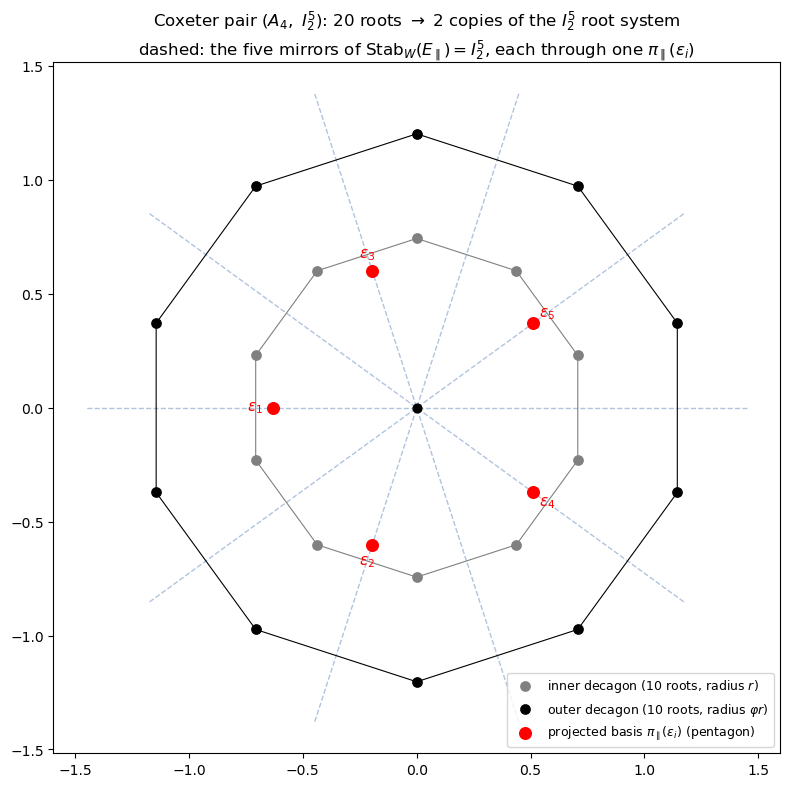

In [7]:
roots = np.array([np.eye(5)[i] - np.eye(5)[j]
                  for i in range(5) for j in range(5) if i != j])
proj_roots = roots @ V_par
norms = np.linalg.norm(proj_roots, axis=1)
r_in, r_out = np.unique(np.round(norms, 9))
phi = (1 + np.sqrt(5)) / 2
m_in, m_out = np.isclose(norms, r_in), np.isclose(norms, r_out)
assert m_in.sum() == m_out.sum() == 10
assert np.isclose(r_out / r_in, phi)
for m in (m_in, m_out):                       # each ring is a regular decagon
    angs = np.sort(np.degrees(np.arctan2(proj_roots[m][:, 1], proj_roots[m][:, 0])))
    assert np.allclose(np.diff(np.append(angs, angs[0] + 360)), 36.0)
print(f"20 roots of A4 -> two regular decagons: radii {r_in:.4f} and {r_out:.4f},")
print(f"ratio = {r_out / r_in:.6f} = phi   ==>   N = 2 copies of the I2(5) root system")

# ---- figure ----------------------------------------------------------------
basis_proj = np.eye(5) @ V_par
fig, ax = plt.subplots(figsize=(8, 8))

L = 1.45
for p in (q for q in D if np.linalg.det(induced(q, V_par)) < 0):
    k = next(i for i in range(5) if p[i] == i)
    u = basis_proj[k] / np.linalg.norm(basis_proj[k])
    ax.plot([-L * u[0], L * u[0]], [-L * u[1], L * u[1]],
            color='lightsteelblue', linestyle='--', linewidth=1.0, zorder=0)

for m, color, lab, r in ((m_in, 'grey', 'inner decagon (10 roots, radius $r$)', r_in),
                         (m_out, 'black', r'outer decagon (10 roots, radius $\varphi r$)', r_out)):
    pts = proj_roots[m]
    ring = pts[np.argsort(np.arctan2(pts[:, 1], pts[:, 0]))]
    ring = np.vstack([ring, ring[0]])
    ax.plot(ring[:, 0], ring[:, 1], color=color, linewidth=0.8, zorder=1)
    ax.scatter(pts[:, 0], pts[:, 1], s=45, color=color, label=lab, zorder=2)

ax.scatter(basis_proj[:, 0], basis_proj[:, 1], s=70, color='red', zorder=3,
           label=r'projected basis $\pi_\parallel(\varepsilon_i)$ (pentagon)')
for i, (x, y) in enumerate(basis_proj):
    ax.annotate(rf'$\varepsilon_{i + 1}$', xy=(1.12 * x, 1.12 * y),
                ha='center', va='center', fontsize=11, color='red')
ax.scatter([0], [0], s=40, color='k', zorder=3)

ax.set_aspect('equal')
ax.set_title(r'Coxeter pair $(A_4,\ I_2^5)$: 20 roots $\to$ 2 copies of the $I_2^5$'
             ' root system\n'
             r'dashed: the five mirrors of $\mathrm{Stab}_W(E_\parallel) = I_2^5$,'
             r' each through one $\pi_\parallel(\varepsilon_i)$')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()